# Implementation of MCP Neuron for AND and OR Function.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)
  ### YOUR CODE HERE ###
  # Perform an element wise addition of two input arrays stored in a new array(list):
  element_wise_sum = [X1[i] + X2[i] for i in range(len(X1))]
  # Create a new array to put all the prediction let's name that a state_neuron.
  state_neuron = []
  # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
  for s in element_wise_sum:
      state_neuron.append(1 if s >= T else 0)

  return state_neuron

In [ ]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    ### YOUR CODE HERE ###
    # Perform an element wise addition of two input arrays stored in a new array(list):
    element_wise_sum = [X1[i] + X2[i] for i in range(len(X1))]
    # Create a new array to put all the prediction let's name that a state_neuron.
    state_neuron = []
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    for s in element_wise_sum:
        state_neuron.append(1 if s >= T else 0)

    return state_neuron


In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


# Implementation for 3 Vs. 5 Classification.

## Step 1: Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
df_full = pd.read_csv("/content/drive/MyDrive/AI ML/Data/mnist_3_and_5.csv")

# Filter to only digits 3 and 5
df_3_5 = df_full[df_full['label'].isin([3, 5])].copy()

# Re-encode labels: 3 → 0, 5 → 1
df_3_5['label'] = df_3_5['label'].map({3: 0, 5: 1})

# Extract features and labels
X = df_3_5.drop(columns=["label"]).values  # 784 pixels
y = df_3_5["label"].values                 # 0 = three, 1 = five

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)
print("Class counts:", dict(zip(*np.unique(y, return_counts=True))))

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)
Class counts: {np.int64(0): np.int64(1484), np.int64(1): np.int64(1257)}


### Viewing the Dataset.

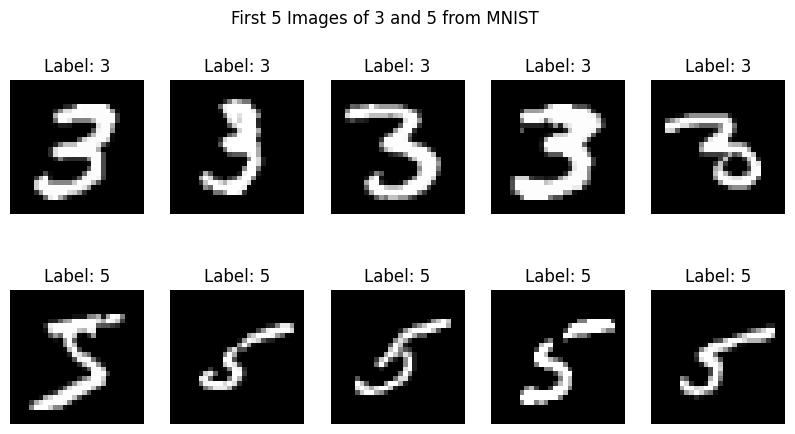

In [ ]:
images_3 = X[y == 0]  # label 0 = digit "3"
images_5 = X[y == 1]  # label 1 = digit "5"

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images.")
else:
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 3 and 5 from MNIST")
    plt.show()

## Step - 2 - Initializing the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Step - 3 - Make a Decision function:

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    # Activation function (step function): output 1 if >= 0, else 0
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    accuracy = 0.0
    for epoch in range(1, epochs + 1):
        correct = 0
        for i in range(len(X)):
            # Compute prediction using step function
            prediction = 1 if (np.dot(X[i], weights) + bias) >= 0 else 0
            # Update weights and bias if prediction is wrong
            error = y[i] - prediction
            weights += learning_rate * error * X[i]
            bias += learning_rate * error
            if prediction == y[i]:
                correct += 1
        accuracy = correct / len(X)
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Accuracy = {accuracy:.4f}")

    return weights, bias, accuracy

## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Epoch 10: Accuracy = 0.9566
Epoch 20: Accuracy = 0.9661
Epoch 30: Accuracy = 0.9726
Epoch 40: Accuracy = 0.9719
Epoch 50: Accuracy = 0.9788
Epoch 60: Accuracy = 0.9759
Epoch 70: Accuracy = 0.9792
Epoch 80: Accuracy = 0.9792
Epoch 90: Accuracy = 0.9843
Epoch 100: Accuracy = 0.9858
The Final Accuracy is:  0.9857716161984678


## Step 5: Visualize Misclassified Images

Final Accuracy: 0.9869


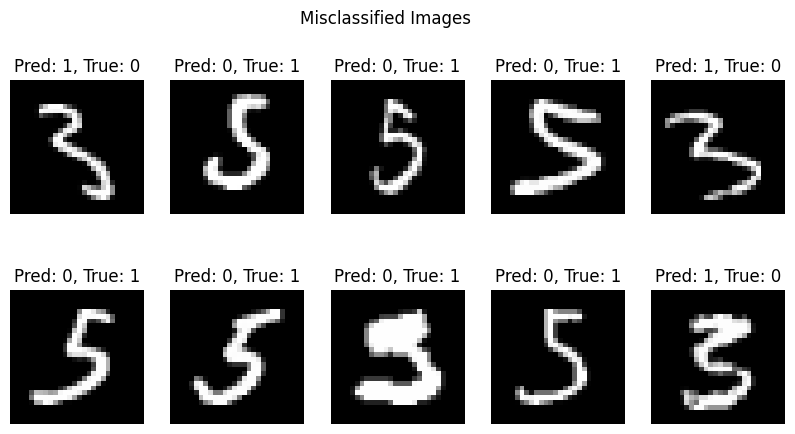

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")